In [516]:
import json
import matplotlib.pyplot as plt
import numpy as np
import time

from itertools import product
import qutip as qt

import h5py
from datetime import datetime
import sys
import os
import shutil
import importlib

sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1")
sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_measurements")
sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_simulations")

sys.path.append(r"E:\Research\Projects\Triangle Lattice\chiral_currents_project\Jupyter Notebooks\8Q_Triangle_Lattice_v1")
sys.path.append(r"E:\Research\Projects\Triangle Lattice\chiral_currents_project\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_measurements")
sys.path.append(r"E:\Research\Projects\Triangle Lattice\chiral_currents_project\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_simulations")


import current_measurements.src.src_current_measurement_simulations
importlib.reload(current_measurements.src.src_current_measurement_simulations);
from current_measurements.src.src_current_measurement_simulations import CurrentMeasurementSimulation

import current_measurements.src.src_current_measurement_simulations_particle_sector
importlib.reload(current_measurements.src.src_current_measurement_simulations_particle_sector);
from current_measurements.src.src_current_measurement_simulations_particle_sector import CurrentMeasurementSimulationParticleSector


import current_simulations.quantum_states
importlib.reload(current_simulations.quantum_states)
from current_simulations.quantum_states import QuantumState, FockBasisState, FockBasisOuter, DensityMatrix

import quantum_states
importlib.reload(quantum_states)
from quantum_states import QuantumState, FockBasisState, FockBasisOuter, DensityMatrix


In [517]:
def convert_particle_sector_to_reduced_density_matrix(psi_4particle, 
                                                      basis_4particle, 
                                                      reduced_qubit_indices, 
                                                      num_qubits=8,
                                                      num_levels=5):
    """
    More efficient version that groups states by their traced configurations
    Handles both state vectors and density matrices as input.

    after reducing to reduced density matrix, truncate to remove states that have more than 4 particles in total
    """
    from collections import defaultdict
    
    # Check if input is a density matrix or state vector
    if hasattr(psi_4particle, 'shape') and len(psi_4particle.shape) == 2:
        # Input is a density matrix
        is_density_matrix = True
        if hasattr(psi_4particle, 'full'):
            rho_input = psi_4particle.full()  # QuTiP Qobj
        else:
            rho_input = psi_4particle  # numpy array
    else:
        # Input is a state vector
        is_density_matrix = False
        if hasattr(psi_4particle, 'full'):
            psi_input = psi_4particle.full().flatten()  # QuTiP Qobj
        else:
            psi_input = psi_4particle.flatten()  # numpy array
    

    if psi_4particle.isket:
        is_density_matrix = False
        psi_input = psi_4particle.full().flatten()

    elif psi_4particle.isoper:
        is_density_matrix = True
        rho_input = psi_4particle.full()



    traced_qubits = [i for i in range(num_qubits) if i not in reduced_qubit_indices]
    
    # Group states by (reduced_config, traced_config)
    state_groups = defaultdict(list)

    # print(f'reduced_qubit_indices: {reduced_qubit_indices}, traced_qubits: {traced_qubits}')
    # print(f'len basis_4particle: {len(basis_4particle)}')
    
    for i, full_state in enumerate(basis_4particle):
        reduced_part = tuple(full_state[j] for j in reduced_qubit_indices)
        traced_part = tuple(full_state[j] for j in traced_qubits)
        state_groups[(reduced_part, traced_part)].append(i)
    
    # Generate basis for reduced qubits
    reduced_basis = list(product(range(num_levels), repeat=len(reduced_qubit_indices)))
    dim_reduced = len(reduced_basis)
    rho_reduced = np.zeros((dim_reduced, dim_reduced), dtype=complex)
    
    # Build density matrix
    for alpha, reduced_alpha in enumerate(reduced_basis):
        for beta, reduced_beta in enumerate(reduced_basis):
            
            matrix_element = 0.0
            
            # Sum over all traced configurations
            all_traced_configs = set()
            for (red_part, traced_part), indices in state_groups.items():
                if red_part == reduced_alpha or red_part == reduced_beta:
                    all_traced_configs.add(traced_part)
            
            for traced_config in all_traced_configs:
                indices_alpha = state_groups.get((reduced_alpha, traced_config), [])
                indices_beta = state_groups.get((reduced_beta, traced_config), [])
                
                if is_density_matrix:
                    # For density matrix input: Tr_traced[rho] = sum over traced indices
                    for i in indices_alpha:
                        for j in indices_beta:
                            matrix_element += rho_input[i, j]
                else:
                    # For state vector input: |psi><psi| -> sum coefficients
                    coeff_alpha = sum(psi_input[i] for i in indices_alpha)
                    coeff_beta = sum(psi_input[i] for i in indices_beta)
                    matrix_element += coeff_alpha * np.conj(coeff_beta)

            rho_reduced[alpha, beta] = matrix_element

    
    basis_4Q_reduced_indices = np.where([sum(state) <= 4 for state in reduced_basis])[0]
    rho_reduced = rho_reduced[basis_4Q_reduced_indices,:][:,basis_4Q_reduced_indices]
    
    return qt.Qobj(rho_reduced, dims=[[len(basis_4Q_reduced_indices)], [len(basis_4Q_reduced_indices)]])

In [518]:
def add_phase(state, number_operators, phase=0):

    n1 = number_operators[0]
    n2 = number_operators[1]

    phase_operator = (-1j * (n2-n1)*phase/2).expm()

    new_state = None
    if state.isket:
        new_state = phase_operator*state
    elif state.isoper:
        new_state = phase_operator*state*phase_operator.dag()

    print(f'adding phase {phase}')

    reduced_basis = list(product(range(5), repeat=2))

    subspace_indices = []
    for i in range(len(reduced_basis)):
        if reduced_basis[i] in [(0,0),(0,1),(1,0),(1,1)]:
            subspace_indices.append(i)

    print(f'phase_operator subspace')

    print(np.round(phase_operator[subspace_indices,:][:,subspace_indices], 2))     
    print(np.round(state[subspace_indices,:][:,subspace_indices], 2))     
    print(np.round(new_state[subspace_indices,:][:,subspace_indices], 2))     

    return new_state

In [519]:
config_filename = 'bond_order_config.json'

with open(config_filename, 'r') as f:
    config = json.load(f)

eigenstate = 'highest'

coupling_point = 'coupling_point_4'
dephasing = 'real'



coupling_point_config = config[coupling_point]


In [520]:
pair_to_simulation = {}


In [521]:
### extract simulation data

simulation_config = coupling_point_config['simulation_config']

num_levels = simulation_config['num_levels']
num_qubits = simulation_config['num_qubits']
num_particles = simulation_config['num_particles']

U = simulation_config['U'] * 2  *np.pi
times = np.linspace(simulation_config['time_start'], simulation_config['time_stop'], simulation_config['time_num_points'])

J = []
J_parallel = []

psi0 = simulation_config['psi0']
T1 = simulation_config['T1']
T2 = simulation_config['T2']

coupling_dict = coupling_point_config['coupling']

for i in range(num_qubits-1):
    J_key = f'J_{i+1}{i+2}'
    J_parallel_key = f'J_{i+1}{i+3}'

    if J_key in coupling_dict:
        J.append(coupling_dict[J_key])

    if J_parallel_key in coupling_dict:
        J_parallel.append(coupling_dict[J_parallel_key])

if not len(J) == num_qubits - 1:
    raise ValueError(f'coupling strengths J not properly specified in config file. Needs all pairs J_<i><i+1>. Given length: {len(J)}')

if not len(J_parallel) == num_qubits - 2:
    raise ValueError(f'coupling strengths J_parallel not properly specified in config file. Needs all pairs J_<i><i+2>. Given length: {len(J_parallel)}')

J = np.array(J)*2*np.pi
J_parallel = np.array(J_parallel)*2*np.pi



In [522]:
def load_nested_dict_from_hdf5(filename):
    def _load_dict(group):
        result = {}
        for key in group.keys():
            if isinstance(group[key], h5py.Group):
                result[key] = _load_dict(group[key])
            else:
                result[key] = group[key][()]  # Load dataset
        
        # Load attributes (scalars)
        for key, value in group.attrs.items():
            result[key] = value
            
        return result
    
    with h5py.File(filename, 'r') as f:
        return _load_dict(f)

In [523]:
### load ramp dephasing state data

ramp_state_filename = '../ramp_dephasing_simulations/ramp_dephasing_states.h5'

# Load the full file structure
ramp_state_data = load_nested_dict_from_hdf5(ramp_state_filename)

print(ramp_state_data[coupling_point][eigenstate].keys())


dict_keys(['no_dephasing_ramp', 'real'])


In [524]:
# create initial state from diagonalizing the particle sector Hamiltonian

initial_detunings = np.zeros(num_qubits)
# initial_detunings[0] = 5*2*np.pi

simulation = CurrentMeasurementSimulationParticleSector(num_levels, num_qubits, num_particles, J, J_parallel, U, times,
                                          [1,2], [3,4], psi0=psi0, T1=T1, T2=T2, initial_detunings=initial_detunings)

if isinstance(dephasing, str) and 'no_dephasing' in dephasing:
    if dephasing == 'no_dephasing_ramp':
        print(f'found state for no dephasing ramp')
        psi0_state = qt.Qobj(ramp_state_data[coupling_point][eigenstate]['no_dephasing_ramp'])
        # convert state vecto to density matrix
        psi0_state = psi0_state * psi0_state.dag()
        simulation.psi0 = psi0_state
else:
    T2_sim = str(dephasing)
    if T2_sim in ramp_state_data[coupling_point][eigenstate]:
        print(f'found state for dephasing T2 = {T2_sim}')
        psi0_state = qt.Qobj(ramp_state_data[coupling_point][eigenstate][T2_sim])
        simulation.psi0 = psi0_state
    else:
        print(f'could not find state for dephasing T2 = {T2_sim}')
        raise KeyError

psi0_state = simulation.psi0

basis = list(product(range(num_levels), repeat=num_qubits))
basis_4Q = [state for state in basis if sum(state) == 4]

basis_indices = np.where([np.all(np.array(state) <= 1) for state in basis_4Q])[0]

H_test = simulation.initial_Hamiltonian
print(np.round(H_test[basis_indices,:][:,basis_indices].real,2))

psi0_state

processing psi0, given type: <class 'int'>
found state for dephasing T2 = real
[[  0.   -41.22  38.33 ...   0.     0.     0.  ]
 [-41.22   0.   -40.09 ...   0.     0.     0.  ]
 [ 38.33 -40.09   0.   ...   0.     0.     0.  ]
 ...
 [  0.     0.     0.   ...   0.   -40.09  38.33]
 [  0.     0.     0.   ... -40.09   0.   -41.22]
 [  0.     0.     0.   ...  38.33 -41.22   0.  ]]


Quantum object: dims=[[330], [330]], shape=(330, 330), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 5.92577876e-11-2.31587749e-25j -1.71120910e-09-3.53261652e-11j
   4.11257388e-09+3.99321569e-11j ...  4.23522847e-10+7.14053326e-11j
  -3.43751828e-10-9.41167285e-11j  1.00066555e-11+2.15225967e-12j]
 [-1.71120910e-09+3.53261652e-11j  5.55921590e-08+5.28012233e-22j
  -1.49175592e-07+1.62115365e-09j ... -1.46204248e-08-1.91023961e-09j
   1.18666184e-08+2.77885976e-09j -3.44575002e-10-6.08001077e-11j]
 [ 4.11257388e-09-3.99321569e-11j -1.49175592e-07-1.62115365e-09j
   5.31511510e-07+1.67439180e-21j ...  5.05722437e-08+9.84710472e-09j
  -4.05326903e-08-1.19659878e-08j  1.18215752e-09+2.79148691e-10j]
 ...
 [ 4.23522847e-10-7.14053326e-11j -1.46204248e-08+1.91023961e-09j
   5.05722437e-08-9.84710472e-09j ...  5.77549184e-08-5.46162555e-22j
  -4.90214739e-08-2.01273235e-09j  1.59445795e-09+2.69294385e-11j]
 [-3.43751828e-10+9.41167285e-11j  1.18666184e-08-2.77885976e-09j
  -4.0532690

In [525]:
def calculate_bond_order_simulation(annihilation_operators, number_operators, initial_state, 
                                             J, J_parallel, U, measurement_detuning, pair,
                                             plot_population=False, capped=True):
    # Initialize timing
    start_time = time.time()
    last_time = start_time

    H_BS_reduced = 0
    
    pair_indices = [q-1 for q in pair]

    print(f'creating Hamiltonian, time elapsed: {time.time() - last_time:.3f}s')
    last_time = time.time()
    
    for i in range(len(number_operators)):
        a_i = annihilation_operators[i]
        q_i = pair_indices[i]
        for j in range(i+1, len(number_operators)):
            q_j = pair_indices[j]
            a_j = annihilation_operators[j]
            coupling = 0

            print(J)
            print(min(q_i, q_j))
            if abs(q_i - q_j) == 1:
                coupling = J[min(q_i, q_j)]

            if abs(q_i - q_j) == 2:
                coupling = J_parallel[min(q_i, q_j)]

            H_BS_reduced += coupling*(a_i.dag()*a_j + a_j.dag()*a_i)

        H_BS_reduced += U/2 * a_i.dag()*a_i*(a_i.dag()*a_i - 1)

        H_BS_reduced += a_i.dag()*a_i*measurement_detuning[q_i]

    print(f'H dims: {H_BS_reduced.dims}')

    # H_basis = list(product(range(5), repeat=2))
    # H_basis_reduced = [state for state in H_basis if sum(state) <= 4]

    # H_basis_reduced_indices = np.where([sum(state) == 1 for state in H_basis_reduced])[0]
    # print(H_basis_reduced_indices)

    # print(H_BS_reduced[H_basis_reduced_indices,:][:,H_basis_reduced_indices])
   
    print(f'running simulation, time elapsed: {time.time() - last_time:.3f}s')
    last_time = time.time()

    result = qt.mesolve(H_BS_reduced, initial_state, times)

    print(f'calculating populations, time elapsed: {time.time() - last_time:.3f}s')
    last_time = time.time()
    
    populations = np.zeros((len(number_operators), len(times)))

    number_operators_measurement = number_operators

    if capped:
        number_operators_capped = [qt.Qobj(np.clip(n.full(), 0, 1), dims=n.dims) for n in number_operators]
        # print(np.diag(number_operators_capped[0].full()))
        number_operators_measurement = number_operators_capped

    for i in range(len(number_operators_measurement)):
        populations[i,:] = qt.expect(number_operators_measurement[i], result.states)

    # print(f'getting population difference between indices {pair_indices}')
    population_difference = populations[1, :] - populations[0, :]

    if plot_population:
        plt.figure(figsize=(8,5))
        for i in range(len(number_operators)):
            plt.plot(times, populations[i,:], label=f'Qubit {pair[i]}')
        plt.xlabel('Time')
        plt.ylabel('Population')
        plt.title('Qubit Populations Over Time')
        plt.legend()
        plt.show()

    return population_difference

In [526]:
### initialiaze reduced operators in 4Q subspace

a = qt.destroy(num_levels)

a_1 = qt.tensor([a, qt.qeye(num_levels)])
a_2 = qt.tensor([qt.qeye(num_levels), a])

annihilation_operators_reduced = [a_1, a_2]
number_operators_reduced = [a_i.dag()*a_i for a_i in annihilation_operators_reduced]


# truncated reduced operators to 4 or fewer particles

reduced_basis = list(product(range(num_levels), repeat=len(annihilation_operators_reduced)))
basis_4Q_reduced_indices = np.where([sum(state) <= 4 for state in reduced_basis])[0]

annihilation_operators_reduced_truncated = []


for i in range(len(annihilation_operators_reduced)):
    a_i = annihilation_operators_reduced[i]
    a_i_truncated = a_i[basis_4Q_reduced_indices,:][:,basis_4Q_reduced_indices]
    annihilation_operators_reduced_truncated.append(qt.Qobj(a_i_truncated, dims=(len(basis_4Q_reduced_indices), len(basis_4Q_reduced_indices))))

number_operators_reduced_truncated = []

for i in range(len(number_operators_reduced)):
    n_i = number_operators_reduced[i]
    n_i_truncated = n_i[basis_4Q_reduced_indices,:][:,basis_4Q_reduced_indices]
    number_operators_reduced_truncated.append(qt.Qobj(n_i_truncated, dims=(len(basis_4Q_reduced_indices), len(basis_4Q_reduced_indices))))




In [527]:
pairs = [(i,i+1) for i in range(1,8)]

In [528]:
pair_to_beamsplitter_time = {}
pair_to_population_difference = {}
pair_to_bond_order_value_BS = {}

pair: (1, 2), time elapsed: 0.000s
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (3, 0), (3, 1), (4, 0)]
adding phase -1.5707963267948966
phase_operator subspace
[[1.  +0.j   0.  +0.j   0.  +0.j   0.  +0.j  ]
 [0.  +0.j   0.71+0.71j 0.  +0.j   0.  +0.j  ]
 [0.  +0.j   0.  +0.j   0.71-0.71j 0.  +0.j  ]
 [0.  +0.j   0.  +0.j   0.  +0.j   1.  +0.j  ]]
[[ 0.19+0.j    0.  +0.j    0.  +0.j    0.  +0.j  ]
 [ 0.  +0.j    0.33-0.j   -0.3 +0.02j  0.  +0.j  ]
 [ 0.  +0.j   -0.3 -0.02j  0.34+0.j    0.  +0.j  ]
 [ 0.  +0.j    0.  +0.j    0.  +0.j    0.14-0.j  ]]
[[ 0.19+0.j   0.  +0.j   0.  +0.j   0.  +0.j ]
 [ 0.  +0.j   0.33-0.j  -0.02-0.3j  0.  +0.j ]
 [ 0.  +0.j  -0.02+0.3j  0.34-0.j   0.  +0.j ]
 [ 0.  +0.j   0.  +0.j   0.  +0.j   0.14-0.j ]]
rho reduced dims: [[15], [15]]
calculating current correlation, time elapsed: 0.021s
creating Hamiltonian, time elapsed: 0.000s
[-39.01858076 -41.28052747 -40.08672226 -41.21769562 -39.96105855
 -41.02920

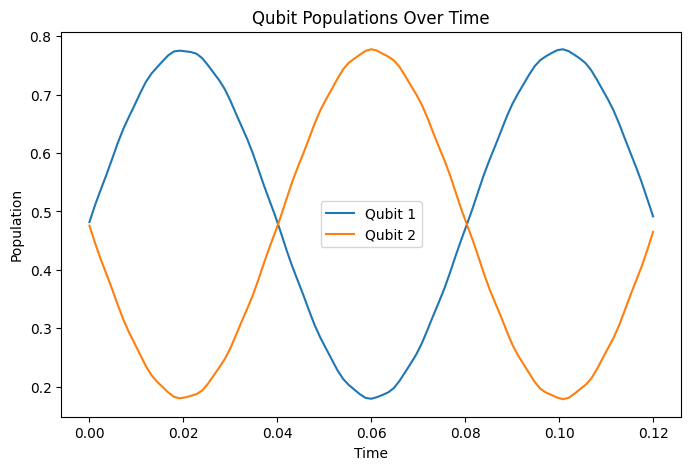

done with correlation pair: (1, 2), time elapsed: 0.213s, 
total iteration time: 0.234s

pair: (2, 3), time elapsed: 0.000s
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (3, 0), (3, 1), (4, 0)]
adding phase -1.5707963267948966
phase_operator subspace
[[1.  +0.j   0.  +0.j   0.  +0.j   0.  +0.j  ]
 [0.  +0.j   0.71+0.71j 0.  +0.j   0.  +0.j  ]
 [0.  +0.j   0.  +0.j   0.71-0.71j 0.  +0.j  ]
 [0.  +0.j   0.  +0.j   0.  +0.j   1.  +0.j  ]]
[[ 0.2 -0.j  0.  +0.j  0.  +0.j  0.  +0.j]
 [ 0.  +0.j  0.32+0.j -0.27-0.j  0.  +0.j]
 [ 0.  +0.j -0.27+0.j  0.28-0.j  0.  +0.j]
 [ 0.  +0.j  0.  +0.j  0.  +0.j  0.2 +0.j]]
[[0.2 -0.j   0.  +0.j   0.  +0.j   0.  +0.j  ]
 [0.  +0.j   0.32+0.j   0.  -0.27j 0.  +0.j  ]
 [0.  +0.j   0.  +0.27j 0.28-0.j   0.  +0.j  ]
 [0.  +0.j   0.  +0.j   0.  +0.j   0.2 +0.j  ]]
rho reduced dims: [[15], [15]]
calculating current correlation, time elapsed: 0.021s
creating Hamiltonian, time elapsed: 0.000s
[-39.01858076 -41.2

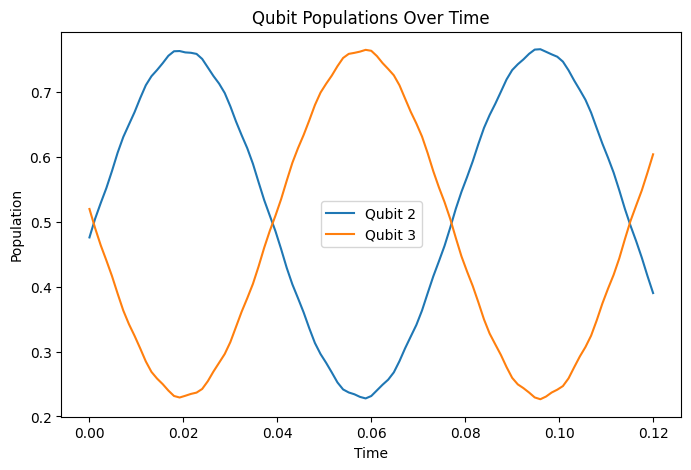

done with correlation pair: (2, 3), time elapsed: 0.186s, 
total iteration time: 0.207s

pair: (3, 4), time elapsed: 0.000s
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (3, 0), (3, 1), (4, 0)]
adding phase -1.5707963267948966
phase_operator subspace
[[1.  +0.j   0.  +0.j   0.  +0.j   0.  +0.j  ]
 [0.  +0.j   0.71+0.71j 0.  +0.j   0.  +0.j  ]
 [0.  +0.j   0.  +0.j   0.71-0.71j 0.  +0.j  ]
 [0.  +0.j   0.  +0.j   0.  +0.j   1.  +0.j  ]]
[[ 0.19-0.j    0.  +0.j    0.  +0.j    0.  +0.j  ]
 [ 0.  +0.j    0.29-0.j   -0.26+0.02j  0.  +0.j  ]
 [ 0.  +0.j   -0.26-0.02j  0.3 +0.j    0.  +0.j  ]
 [ 0.  +0.j    0.  +0.j    0.  +0.j    0.21+0.j  ]]
[[ 0.19-0.j    0.  +0.j    0.  +0.j    0.  +0.j  ]
 [ 0.  +0.j    0.29-0.j   -0.02-0.26j  0.  +0.j  ]
 [ 0.  +0.j   -0.02+0.26j  0.3 +0.j    0.  +0.j  ]
 [ 0.  +0.j    0.  +0.j    0.  +0.j    0.21+0.j  ]]
rho reduced dims: [[15], [15]]
calculating current correlation, time elapsed: 0.021s
creating Hamil

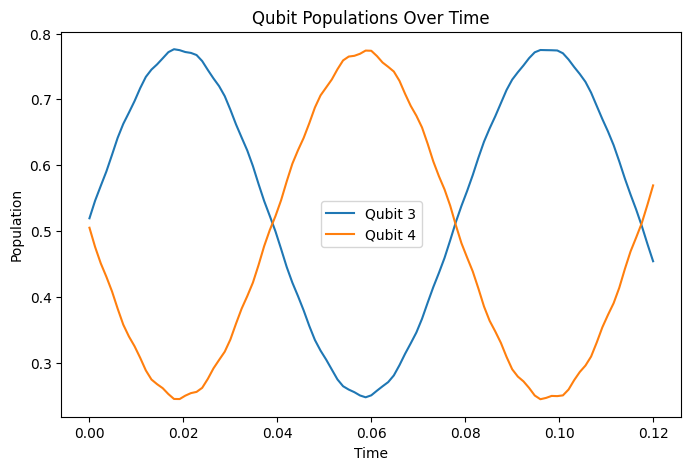

done with correlation pair: (3, 4), time elapsed: 0.187s, 
total iteration time: 0.208s

pair: (4, 5), time elapsed: 0.000s
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (3, 0), (3, 1), (4, 0)]
adding phase -1.5707963267948966
phase_operator subspace
[[1.  +0.j   0.  +0.j   0.  +0.j   0.  +0.j  ]
 [0.  +0.j   0.71+0.71j 0.  +0.j   0.  +0.j  ]
 [0.  +0.j   0.  +0.j   0.71-0.71j 0.  +0.j  ]
 [0.  +0.j   0.  +0.j   0.  +0.j   1.  +0.j  ]]
[[ 0.21+0.j  0.  +0.j  0.  +0.j  0.  +0.j]
 [ 0.  +0.j  0.29-0.j -0.26+0.j  0.  +0.j]
 [ 0.  +0.j -0.26-0.j  0.29+0.j  0.  +0.j]
 [ 0.  +0.j  0.  +0.j  0.  +0.j  0.21-0.j]]
[[ 0.21+0.j    0.  +0.j    0.  +0.j    0.  +0.j  ]
 [ 0.  +0.j    0.29-0.j   -0.  -0.26j  0.  +0.j  ]
 [ 0.  +0.j   -0.  +0.26j  0.29-0.j    0.  +0.j  ]
 [ 0.  +0.j    0.  +0.j    0.  +0.j    0.21-0.j  ]]
rho reduced dims: [[15], [15]]
calculating current correlation, time elapsed: 0.021s
creating Hamiltonian, time elapsed: 0.000s
[-3

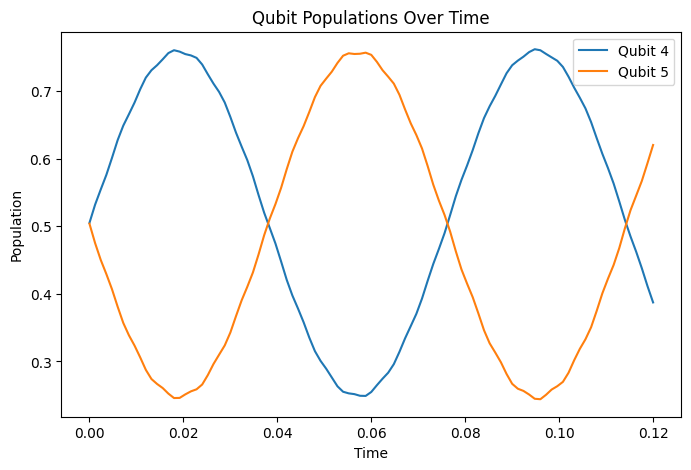

done with correlation pair: (4, 5), time elapsed: 0.177s, 
total iteration time: 0.199s

pair: (5, 6), time elapsed: 0.000s
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (3, 0), (3, 1), (4, 0)]
adding phase -1.5707963267948966
phase_operator subspace
[[1.  +0.j   0.  +0.j   0.  +0.j   0.  +0.j  ]
 [0.  +0.j   0.71+0.71j 0.  +0.j   0.  +0.j  ]
 [0.  +0.j   0.  +0.j   0.71-0.71j 0.  +0.j  ]
 [0.  +0.j   0.  +0.j   0.  +0.j   1.  +0.j  ]]
[[ 0.19+0.j    0.  +0.j    0.  +0.j    0.  +0.j  ]
 [ 0.  +0.j    0.3 +0.j   -0.26-0.03j  0.  +0.j  ]
 [ 0.  +0.j   -0.26+0.03j  0.29-0.j    0.  +0.j  ]
 [ 0.  +0.j    0.  +0.j    0.  +0.j    0.21-0.j  ]]
[[0.19+0.j   0.  +0.j   0.  +0.j   0.  +0.j  ]
 [0.  +0.j   0.3 +0.j   0.03-0.26j 0.  +0.j  ]
 [0.  +0.j   0.03+0.26j 0.29-0.j   0.  +0.j  ]
 [0.  +0.j   0.  +0.j   0.  +0.j   0.21-0.j  ]]
rho reduced dims: [[15], [15]]
calculating current correlation, time elapsed: 0.021s
creating Hamiltonian, time ela

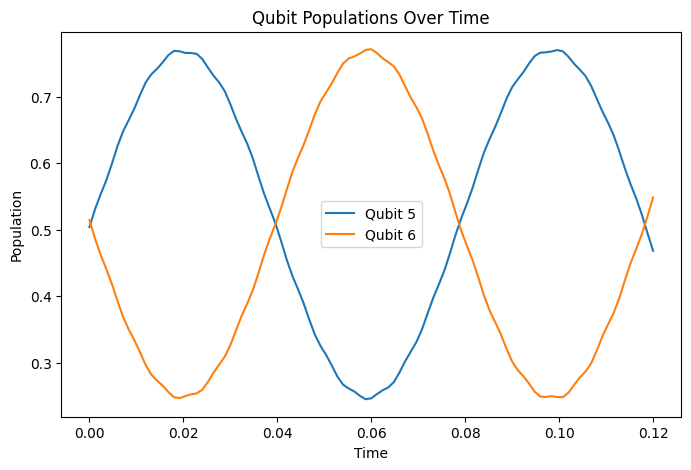

done with correlation pair: (5, 6), time elapsed: 0.184s, 
total iteration time: 0.205s

pair: (6, 7), time elapsed: 0.000s
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (3, 0), (3, 1), (4, 0)]
adding phase -1.5707963267948966
phase_operator subspace
[[1.  +0.j   0.  +0.j   0.  +0.j   0.  +0.j  ]
 [0.  +0.j   0.71+0.71j 0.  +0.j   0.  +0.j  ]
 [0.  +0.j   0.  +0.j   0.71-0.71j 0.  +0.j  ]
 [0.  +0.j   0.  +0.j   0.  +0.j   1.  +0.j  ]]
[[ 0.2 -0.j  0.  +0.j  0.  +0.j  0.  +0.j]
 [ 0.  +0.j  0.28+0.j -0.27+0.j  0.  +0.j]
 [ 0.  +0.j -0.27-0.j  0.31+0.j  0.  +0.j]
 [ 0.  +0.j  0.  +0.j  0.  +0.j  0.2 -0.j]]
[[ 0.2 -0.j    0.  +0.j    0.  +0.j    0.  +0.j  ]
 [ 0.  +0.j    0.28+0.j   -0.  -0.27j  0.  +0.j  ]
 [ 0.  +0.j   -0.  +0.27j  0.31+0.j    0.  +0.j  ]
 [ 0.  +0.j    0.  +0.j    0.  +0.j    0.2 -0.j  ]]
rho reduced dims: [[15], [15]]
calculating current correlation, time elapsed: 0.021s
creating Hamiltonian, time elapsed: 0.000s
[-3

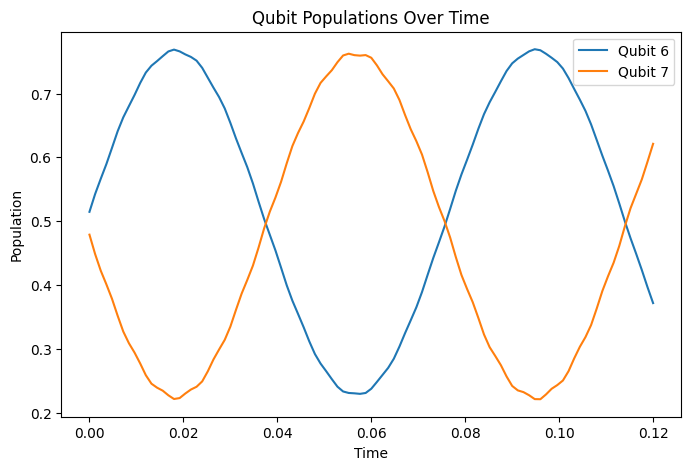

done with correlation pair: (6, 7), time elapsed: 0.194s, 
total iteration time: 0.215s

pair: (7, 8), time elapsed: 0.000s
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (3, 0), (3, 1), (4, 0)]
adding phase -1.5707963267948966
phase_operator subspace
[[1.  +0.j   0.  +0.j   0.  +0.j   0.  +0.j  ]
 [0.  +0.j   0.71+0.71j 0.  +0.j   0.  +0.j  ]
 [0.  +0.j   0.  +0.j   0.71-0.71j 0.  +0.j  ]
 [0.  +0.j   0.  +0.j   0.  +0.j   1.  +0.j  ]]
[[ 0.19-0.j    0.  +0.j    0.  +0.j    0.  +0.j  ]
 [ 0.  +0.j    0.33+0.j   -0.29-0.02j  0.  +0.j  ]
 [ 0.  +0.j   -0.29+0.02j  0.32-0.j    0.  +0.j  ]
 [ 0.  +0.j    0.  +0.j    0.  +0.j    0.15+0.j  ]]
[[0.19-0.j   0.  +0.j   0.  +0.j   0.  +0.j  ]
 [0.  +0.j   0.33+0.j   0.02-0.29j 0.  +0.j  ]
 [0.  +0.j   0.02+0.29j 0.32-0.j   0.  +0.j  ]
 [0.  +0.j   0.  +0.j   0.  +0.j   0.15+0.j  ]]
rho reduced dims: [[15], [15]]
calculating current correlation, time elapsed: 0.021s
creating Hamiltonian, time ela

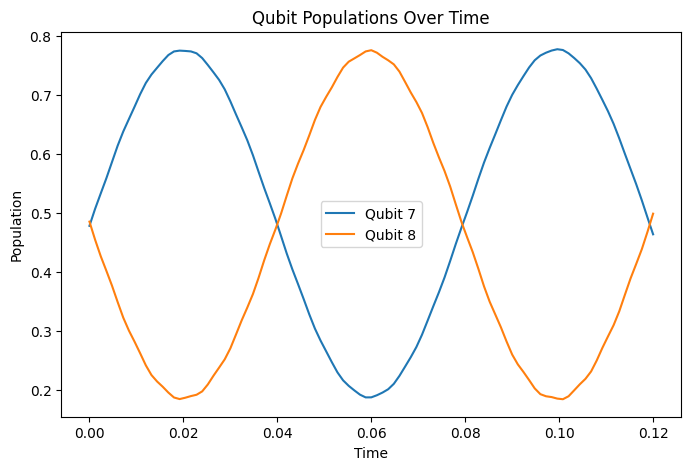

done with correlation pair: (7, 8), time elapsed: 0.203s, 
total iteration time: 0.225s



In [529]:
for pair in pairs:
    # Initialize timing for this iteration
    iteration_start_time = time.time()
    last_time = iteration_start_time

    
    # config_pair_dict = coupling_point_config[str(correlation_pair)]

    if not pair in pair_to_population_difference:

        print(f'pair: {pair}, time elapsed: {time.time() - last_time:.3f}s')
        last_time = time.time()

        if pair[0] % 2 == 1:
            configuration = '12-34-56-78'
        else:
            configuration = '1-23-45-67-8'

        pair_indices = [q-1 for q in pair]

        measurement_detuning = coupling_point_config['data_config'][configuration]['measurement_detunings']

        # simulation beamsplitter time is not the same as the measured beamsplitter time
        J_pair = abs(J[min(pair)-1])  # MHz
        beamsplitter_time_simulation = np.pi/(4*J_pair) # in mus

        pair_to_beamsplitter_time[pair] = beamsplitter_time_simulation

        # print(f'beamsplitter_time_simulation: {beamsplitter_time_simulation*1e3} ns')

        last_time = time.time()

        rho_reduced = convert_particle_sector_to_reduced_density_matrix(psi0_state, 
                                                  basis_4Q, 
                                                  pair_indices, 
                                                  num_qubits=num_qubits,
                                                  num_levels=num_levels)
        
        print([state for state in reduced_basis if sum(state) <= 4])
        rho_reduced = add_phase(rho_reduced, number_operators_reduced_truncated, phase=-np.pi/2)

        # rho_reduced = psi0_state.ptrace(readout_pair_1 + readout_pair_2)
        
        
        print(f'rho reduced dims: {rho_reduced.dims}')

        print(f'calculating current correlation, time elapsed: {time.time() - last_time:.3f}s')
        last_time = time.time()

        population_difference = calculate_bond_order_simulation(annihilation_operators_reduced_truncated, number_operators_reduced_truncated, rho_reduced, 
                                             J, J_parallel, U, measurement_detuning, pair,
                                             plot_population=True, capped=True)

        pair_to_population_difference[pair] = population_difference

        beamsplitter_index = np.argmin(np.abs(times - beamsplitter_time_simulation))
        bond_order_value = population_difference[beamsplitter_index]

        pair_to_bond_order_value_BS[pair] = bond_order_value

        # Calculate total iteration time
        total_iteration_time = time.time() - iteration_start_time
        print(f'done with correlation pair: {pair}, time elapsed: {time.time() - last_time:.3f}s, ')
        print(f'total iteration time: {total_iteration_time:.3f}s')
        print()


bond_order_total_BS = 0
for pair in pairs:
    bond_order_total_BS += pair_to_bond_order_value_BS[pair] * (-1)**(pair[0]-1)  # alternating sign

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Matt\AppData\Local\Temp\ipykernel_13204\3320676053.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('t ($\mu$s)')


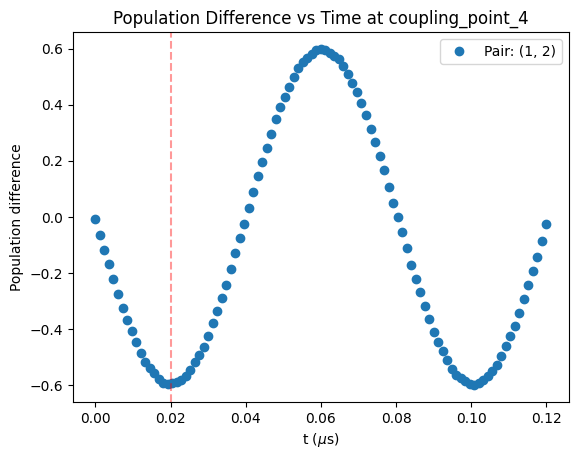

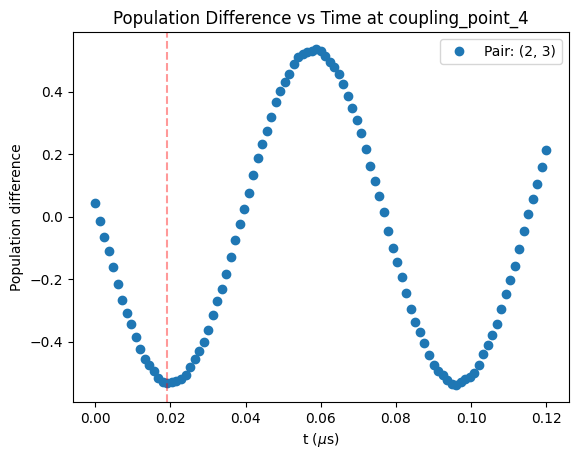

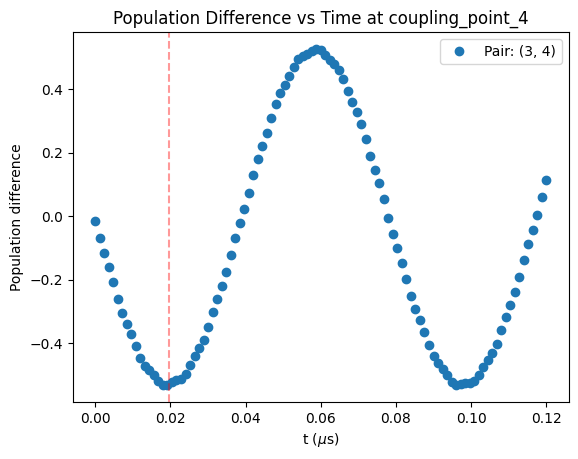

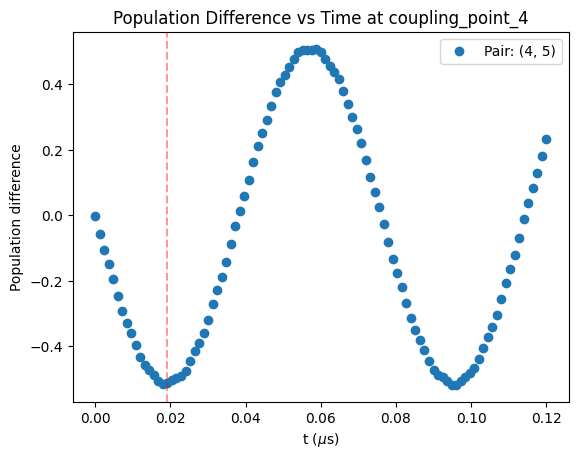

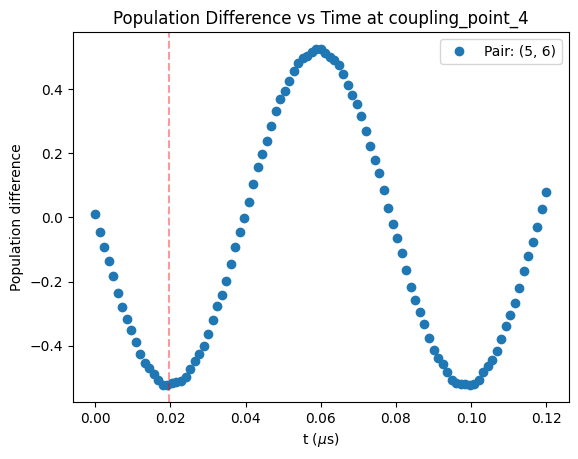

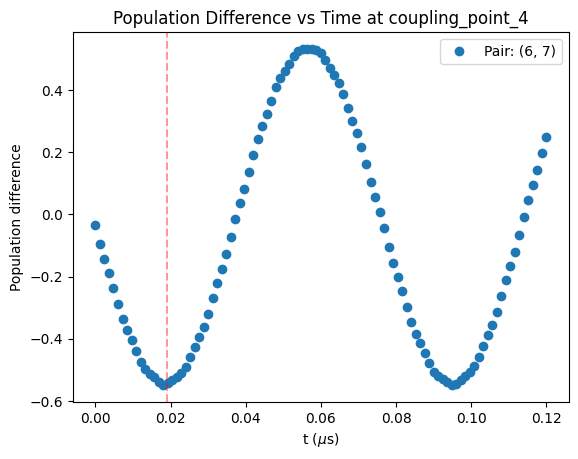

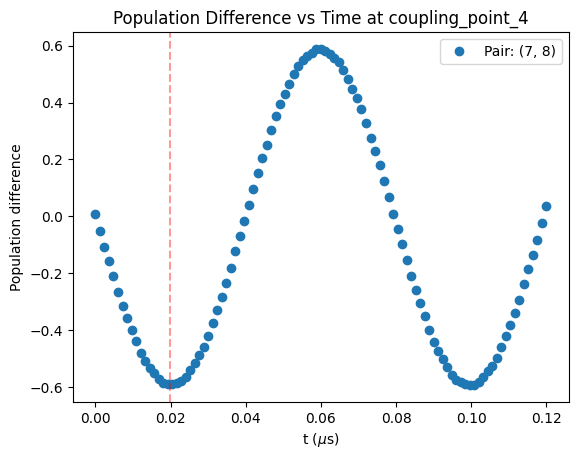

In [530]:
for pair in pairs:

    population_difference = pair_to_population_difference[pair]

    beamsplitter_time_simulation = pair_to_beamsplitter_time[pair]

    plt.plot(times, population_difference, linestyle='', marker='o', label=f'Pair: {pair}')
    plt.xlabel('t ($\mu$s)')
    plt.ylabel('Population difference')
    plt.title(f'Population Difference vs Time at {coupling_point}')

    # plt.ylim(-0.4, 0.4)

    plt.axvline(beamsplitter_time_simulation, color='r', alpha=0.4, linestyle='--')

    plt.legend()
    plt.show()
    

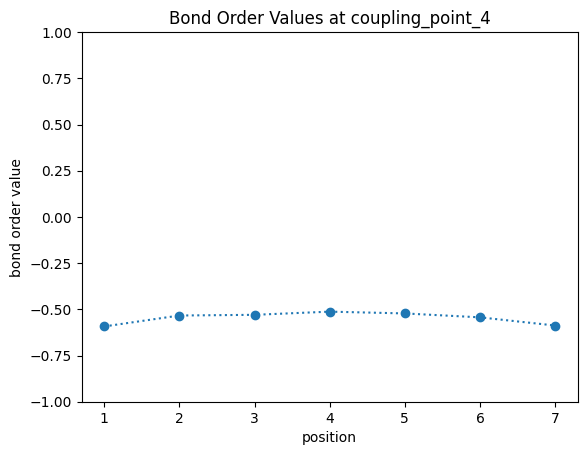

In [531]:
### plot bond order values

bond_order_values_BS = [pair_to_bond_order_value_BS[pair] for pair in pairs]
positions = [pair[0] for pair in pairs]

plt.plot(positions, bond_order_values_BS, linestyle=':', marker='o')

plt.xlabel('position')
plt.ylabel('bond order value')

plt.ylim(-1, 1)

plt.title(f'Bond Order Values at {coupling_point}')

plt.show()


In [532]:
# data_dictionary = {}

# for pair in pairs:

#     data_dictionary[pair] = {}


#     data_dictionary[pair]['beamsplitter_time'] = pair_to_beamsplitter_time[pair]

#     data_dictionary[pair]['population_difference'] = pair_to_population_difference[pair]
#     data_dictionary[pair]['bond_order_value_BS'] = pair_to_bond_order_value_BS[pair]

# data_dictionary['bond_order_total_BS'] = bond_order_total_BS

In [533]:
def backup_data(data_filename):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_only = os.path.basename(data_filename)
    name, ext = os.path.splitext(filename_only)
    backup_name = f"{name}_{timestamp}{ext}"
    backup_path = os.path.join('data_backups', backup_name)
    shutil.copy2(data_filename, backup_path)

def save_nested_dict_to_hdf5(filename, data, save_backup=True):

    if save_backup:
        backup_data(filename)

    with h5py.File(filename, 'w') as f:
        def _save_dict(group, dictionary):
            for key, value in dictionary.items():
                if isinstance(value, dict):
                    subgroup = group.create_group(str(key))
                    _save_dict(subgroup, value)
                elif isinstance(value, np.ndarray):
                    group.create_dataset(key, data=value, compression='gzip')
                elif isinstance(value, list):
                    group.create_dataset(key, data=np.array(value), compression='gzip')
                else:
                    group.attrs[key] = value  # Store scalars as attributes
        
        _save_dict(f, data)

def update_data_file(filename, data, keys, save_backup=True):
    if save_backup:
        backup_data(filename)
    
    with h5py.File(filename, 'a') as f:  # Open in append mode
        def _navigate_to_parent(group, key_path):
            """Navigate to the parent group of the target location"""
            current_group = group
            for key in key_path[:-1]:  # All keys except the last one
                if str(key) in current_group:
                    current_group = current_group[str(key)]
                else:
                    # Create the group if it doesn't exist
                    current_group = current_group.create_group(str(key))
            return current_group
        
        def _save_data_at_location(group, key, value):
            """Save data at a specific location, replacing if it exists"""
            # Remove existing data if it exists
            if key in group:
                del group[key]
            
            # Save new data
            if isinstance(value, dict):
                subgroup = group.create_group(key)
                _save_dict(subgroup, value)
            elif isinstance(value, np.ndarray):
                group.create_dataset(key, data=value, compression='gzip')
            elif isinstance(value, list):
                group.create_dataset(key, data=np.array(value), compression='gzip')
            else:
                group.attrs[key] = value  # Store scalars as attributes
        
        def _save_dict(group, dictionary):
            """Helper function to save nested dictionaries"""
            for key, value in dictionary.items():
                _save_data_at_location(group, str(key), value)
        
        # Navigate to the parent location
        parent_group = _navigate_to_parent(f, keys)
        
        # Save the data at the final key location
        final_key = str(keys[-1])
        _save_data_at_location(parent_group, final_key, data)

In [534]:
# data_filename = 'current_correlations_data.h5'

# this overwrits the whole file !!! be careful
# save_nested_dict_to_hdf5(data_filename, {coupling_point: data_dictionary})

In [535]:
# data_filename = 'bond_order_data.h5'

# keys = ('simulation', 'highest', 'no_dephasing', coupling_point)

# update_data_file(data_filename, data_dictionary, keys=keys, save_backup=True)


# 2. Exact Operator Measurement

In [536]:
current_simulation = CurrentSimulation(num_levels, num_qubits, num_particles, J_parallel, J, 0, U)


In [537]:
# create fock state out of psi0

basis_4Q_fock = [FockBasisState(state) for state in basis_4Q]

if psi0_state.isket:
    psi0_fock = QuantumState(psi0_state.full()[:,0], basis_4Q_fock)
elif psi0_state.isoper:
    psi0_fock_basis = []
    psi0_fock_state = []

    trace_sum = 0

    for i in range(len(basis_4Q)):
        for j in range(len(basis_4Q)):
            coeff = psi0_state.full()[i,j]
            if abs(coeff) > 1e-10:
                psi0_fock_basis.append(FockBasisOuter(basis_4Q[i], basis_4Q[j]))
                psi0_fock_state.append(coeff)

        trace_sum += psi0_state.full()[i,i]

    psi0_fock = DensityMatrix(np.array(psi0_fock_state), psi0_fock_basis)



In [538]:
bond_order_value_from_operator = {}

for pair in pairs:
    value = None
    if isinstance(psi0_fock, QuantumState):
        new_state = psi0_fock.apply_raising_operator(pair[0]-1, num_levels).apply_lowering_operator(pair[1]-1)
        value = psi0_fock.inner_product(new_state)
    elif isinstance(psi0_fock, DensityMatrix):
        new_state = psi0_fock.apply_raising_operator_left(pair[0]-1, num_levels).apply_lowering_operator_left(pair[1]-1)
        value = new_state.trace()
    bond_order_value_from_operator[pair] = 2*value.real

bond_order_value_operators = np.array([bond_order_value_from_operator[pair] for pair in bond_order_value_from_operator])

bond_order_total_operator = 0
for pair in pairs:
    bond_order_total_operator += pair_to_bond_order_value_BS[pair] * (-1)**(pair[0]-1)  # alternating sign    

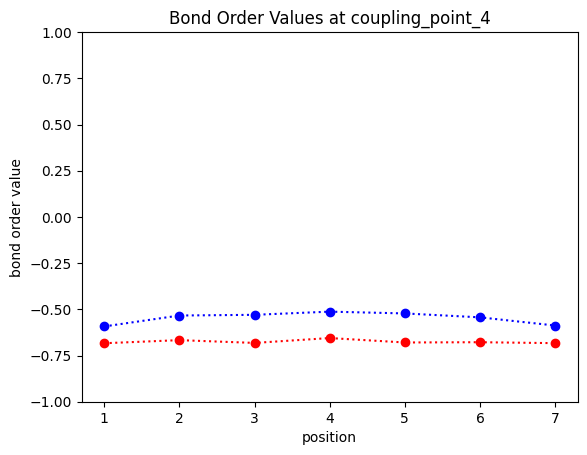

In [539]:
### plot bond order values

positions = [pair[0] for pair in pairs]

plt.plot(positions, bond_order_values_BS, color='blue', linestyle=':', marker='o')
plt.plot(positions, bond_order_value_operators, color='red', linestyle=':', marker='o')

plt.xlabel('position')
plt.ylabel('bond order value')

plt.ylim(-1, 1)

plt.title(f'Bond Order Values at {coupling_point}')

plt.show()


In [540]:
data_dictionary = {}

for pair in pairs:

    data_dictionary[pair] = {}


    data_dictionary[pair]['beamsplitter_time'] = pair_to_beamsplitter_time[pair]

    data_dictionary[pair]['population_difference'] = pair_to_population_difference[pair]
    data_dictionary[pair]['bond_order_value_BS'] = pair_to_bond_order_value_BS[pair]
    data_dictionary[pair]['bond_order_value'] = bond_order_value_from_operator[pair]

data_dictionary['bond_order_total_BS'] = bond_order_total_BS
data_dictionary['bond_order_total'] = bond_order_total_operator

In [541]:
data_filename = 'bond_order_data.h5'

keys = ('simulation', eigenstate, dephasing, coupling_point)

update_data_file(data_filename, data_dictionary, keys=keys, save_backup=True)
